In [6]:
# CELL 1: Install YOLOv8 and verify our dataset
!pip install ultralytics -q  # -q means "quiet", less messy output

import os
from pathlib import Path

# Where Kaggle puts the dataset
DATASET_ROOT = Path("/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset")

# Let's verify every folder exists and count files
splits = {
    "Train": DATASET_ROOT / "VisDrone2019-DET-train",
    "Val":   DATASET_ROOT / "VisDrone2019-DET-val",
    "Test":  DATASET_ROOT / "VisDrone2019-DET-test-dev",
}

print("=" * 50)
print("DATASET VERIFICATION REPORT")
print("=" * 50)

all_good = True
for split_name, split_path in splits.items():
    img_path = split_path / "images"
    lbl_path = split_path / "labels"
    
    # Count files
    images = sorted([f.stem for f in img_path.glob("*.jpg")] + 
                    [f.stem for f in img_path.glob("*.png")])
    
    if lbl_path.exists():
        labels = sorted([f.stem for f in lbl_path.glob("*.txt")])
        matched = len(set(images) & set(labels))
        only_img = len(set(images) - set(labels))
        only_lbl = len(set(labels) - set(images))
        
        print(f"\n{split_name}:")
        print(f"  Images:  {len(images)}")
        print(f"  Labels:  {len(labels)}")
        print(f"  Matched pairs: {matched} ✓")
        if only_img > 0:
            print(f"  ⚠ Images WITHOUT labels: {only_img}")
            all_good = False
        if only_lbl > 0:
            print(f"  ⚠ Labels WITHOUT images: {only_lbl}")
            all_good = False
    else:
        print(f"\n{split_name}: No labels folder (test-challenge is normal)")

print("\n" + "=" * 50)
if all_good:
    print("✅ Dataset is CLEAN — all images have matching labels!")
else:
    print("⚠ Some mismatches found (see above)")
print("=" * 50)

DATASET VERIFICATION REPORT

Train:
  Images:  6471
  Labels:  6471
  Matched pairs: 6471 ✓

Val:
  Images:  548
  Labels:  548
  Matched pairs: 548 ✓

Test:
  Images:  1610
  Labels:  1610
  Matched pairs: 1610 ✓

✅ Dataset is CLEAN — all images have matching labels!


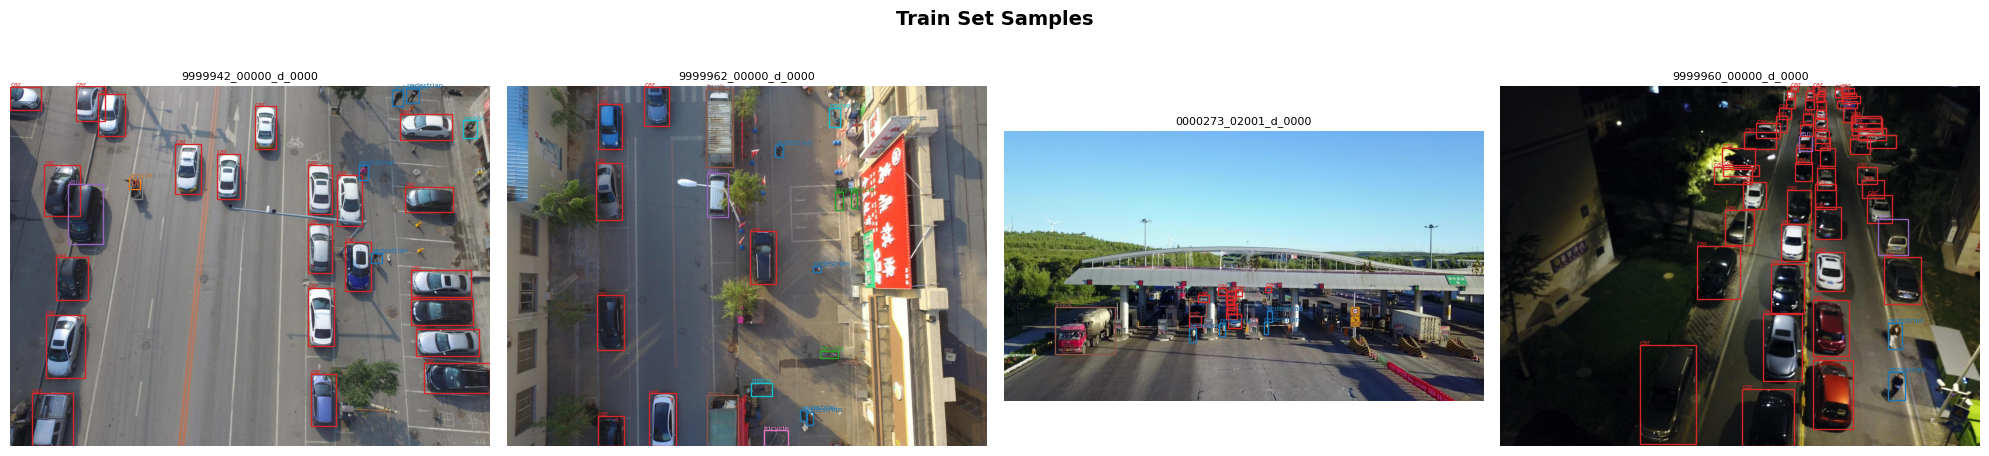

Saved to /kaggle/working/


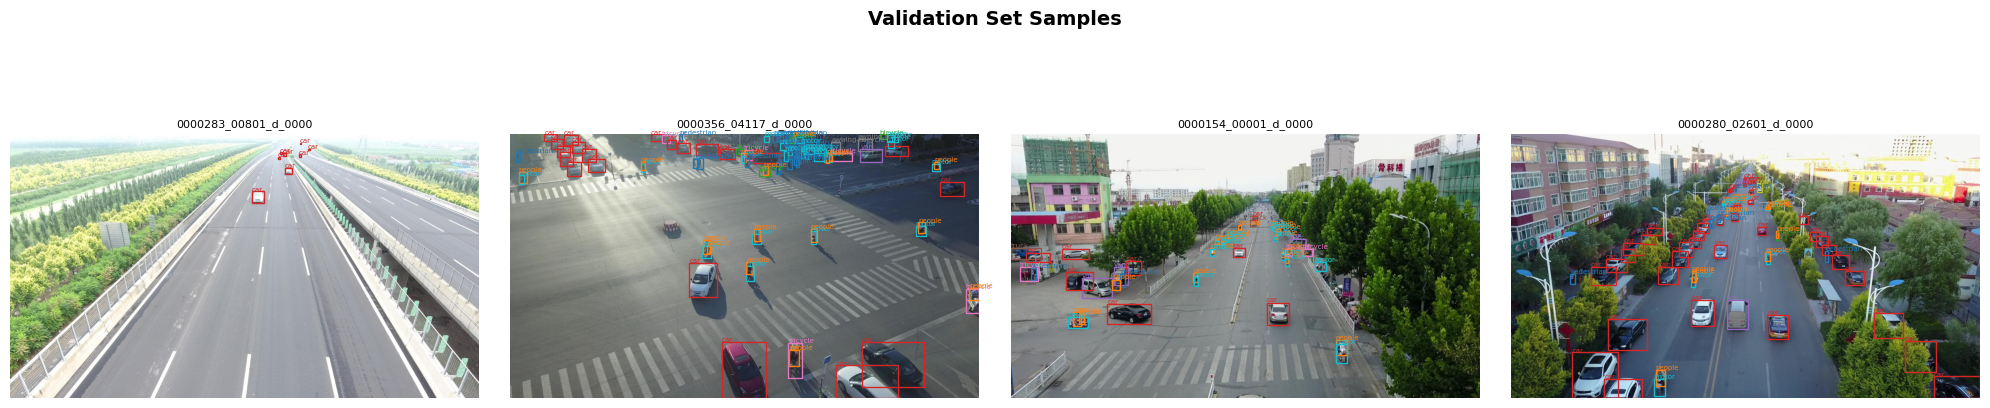

Saved to /kaggle/working/


In [7]:
# CELL 2: Visualize sample images with their bounding boxes (Task 1)
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import random

# Class names and colors (one color per class for clarity)
CLASS_NAMES = ['pedestrian','people','bicycle','car','van',
               'truck','tricycle','awning-tricycle','bus','motor']
COLORS = plt.get_cmap('tab10', 10)

def show_sample_images(split_path, num_samples=4, title="Sample"):
    img_dir = split_path / "images"
    lbl_dir = split_path / "labels"
    
    all_imgs = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    samples = random.sample(all_imgs, min(num_samples, len(all_imgs)))
    
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    for ax, img_path in zip(axes, samples):
        # Load image
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        ax.imshow(img)
        ax.set_title(img_path.name[:20], fontsize=8)
        ax.axis('off')
        
        # Load corresponding label file
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:5])
                    
                    # Convert from YOLO format (0-1 ratios) to pixel coords
                    x1 = (cx - bw/2) * w
                    y1 = (cy - bh/2) * h
                    
                    color = COLORS(cls)[:3]
                    rect = patches.Rectangle(
                        (x1, y1), bw*w, bh*h,
                        linewidth=1, edgecolor=color, facecolor='none'
                    )
                    ax.add_patch(rect)
                    ax.text(x1, y1-2, CLASS_NAMES[cls], 
                            fontsize=5, color=color)
    
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{title.replace(' ','_')}.png", 
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to /kaggle/working/")

# Run for train set
random.seed(42)  # So results are reproducible
show_sample_images(splits["Train"], title="Train Set Samples")
show_sample_images(splits["Val"], title="Validation Set Samples")

In [8]:
# CELL 3: Write the dataset config file that YOLOv8 needs
import yaml

# We write the YAML pointing to Kaggle's input paths
config = {
    'path': '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset',
    'train': 'VisDrone2019-DET-train/images',
    'val':   'VisDrone2019-DET-val/images',
    'test':  'VisDrone2019-DET-test-dev/images',
    'nc': 10,
    'names': CLASS_NAMES
}

config_path = '/kaggle/working/visdrone.yaml'
with open(config_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print("✅ visdrone.yaml written to:", config_path)
print("\nContents:")
with open(config_path) as f:
    print(f.read())

✅ visdrone.yaml written to: /kaggle/working/visdrone.yaml

Contents:
names:
- pedestrian
- people
- bicycle
- car
- van
- truck
- tricycle
- awning-tricycle
- bus
- motor
nc: 10
path: /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset
test: VisDrone2019-DET-test-dev/images
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images



In [ ]:
# CELL 4: TRAIN YOLOv8s on VisDrone
# YOLOv8s = "small" model — good balance of speed and accuracy
from ultralytics import YOLO

# Load a pretrained YOLOv8s model (pretrained on COCO dataset)
# We "fine-tune" it on VisDrone — much faster than training from scratch
model = YOLO('yolov8s.pt')

# Start training!
results = model.train(
    data='/kaggle/working/visdrone.yaml',
    epochs=45,          # 30 passes through the whole dataset
    imgsz=640,          # image size in pixels
    batch=16,           # process 16 images at once (fits P100 memory)
    workers=2,
    device=0,           # use GPU (device 0)
    project='/kaggle/working/runs',
    name='visdrone_train',
    
    # Augmentation (makes model more robust — built into ultralytics)
    hsv_h=0.015,        # slight color shifts
    hsv_s=0.7,
    hsv_v=0.4,
    flipud=0.1,         # drone images can be flipped
    fliplr=0.5,
    mosaic=1.0,         # mixes 4 images (great for small objects)
    
    # Save best model
    save=True,
    save_period=5,      # save checkpoint every 5 epochs
    
    verbose=True        # show progress
)

print("\n✅ TRAINING COMPLETE!")
print(f"Best model saved at: /kaggle/working/runs/visdrone_train/weights/best.pt")

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/visdrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=45, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=visdrone_train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

In [ ]:
# RESUME INTERRUPTED TRAINING

from ultralytics import YOLO
from pathlib import Path

# Find available last.pt checkpoints
last_ckpts = sorted(Path('/kaggle/working/runs').rglob('weights/last.pt'))

print("Found checkpoints:")
for i, p in enumerate(last_ckpts):
    print(i, p)

# Pick the most recently modified last.pt
last_ckpt = max(last_ckpts, key=lambda p: p.stat().st_mtime)
print("\nResuming from:", last_ckpt)

model = YOLO(str(last_ckpt))

results = model.train(resume=True)

In [ ]:
# CELL 4-B: Resume training for 20 more epochs from the best checkpoint.
# Only run this if the results.png graph shows mAP still climbing at epoch 30.
# If the mAP line was already flat, skip this cell entirely.

from ultralytics import YOLO

# Load the best weights from the first run — NOT yolov8s.pt (that's the base model)
# We're continuing from where we left off, not starting over
model_resume = YOLO('/kaggle/working/runs/visdrone_train/weights/last.pt')
# Note: we use last.pt, not best.pt — last.pt is the most recent checkpoint,
# which is the right starting point for continuing training.

results_resumed = model_resume.train(
    data='/kaggle/working/visdrone.yaml',
    epochs=6,          # Total epochs including the previous 30.
                        # Ultralytics counts from 0, so this adds 20 more epochs.
    imgsz=640,
    batch=16,
    workers=2,
    device=0,
    project='/kaggle/working/runs',
    name='visdrone_resumed',   # Saves to a new folder so nothing gets overwritten
    resume=True,               # THIS is the key flag — tells it to continue
    verbose=True
)

print("\n✅ Resumed training complete!")

In [ ]:
# CELL 5: Look at training results
# Auto-detect whichever run has the better mAP
import pandas as pd
from pathlib import Path
from IPython.display import Image as IPImage, display

run_dirs = {
    'Original (30 ep)': Path('/kaggle/working/runs/visdrone_train'),
    'Resumed (4-B)':    Path('/kaggle/working/runs/visdrone_resumed'),
}

for run_name, results_dir in run_dirs.items():
    metrics_file = results_dir / 'results.csv'
    if not metrics_file.exists():
        print(f"{run_name}: not found, skipping")
        continue

    df = pd.read_csv(metrics_file)
    df.columns = df.columns.str.strip()
    best_map = df['metrics/mAP50(B)'].max()
    best_epoch = df['metrics/mAP50(B)'].idxmax() + 1
    print(f"\n{run_name}:")
    print(f"  Best mAP@50:    {best_map:.4f}  (epoch {best_epoch})")
    print(f"  Best mAP@50-95: {df['metrics/mAP50-95(B)'].max():.4f}")

    results_img = results_dir / 'results.png'
    if results_img.exists():
        print(f"  Training curve:")
        display(IPImage(str(results_img), width=900))
# Define best model path — used by all cells below
MODEL_PATH = '/kaggle/working/runs/visdrone_resumed/weights/best.pt' \
    if Path('/kaggle/working/runs/visdrone_resumed/weights/best.pt').exists() \
    else '/kaggle/working/runs/visdrone_train/weights/best.pt'
print(f"\n✅ Using model: {MODEL_PATH}")

In [ ]:
from pathlib import Path

root = Path('/kaggle/input')

print("Datasets mounted:")
for p in root.iterdir():
    print(p)

In [ ]:
from pathlib import Path

root = Path('/kaggle/input')

image_dirs = []
for d in root.rglob('images'):
    imgs = list(d.glob('*.jpg')) + list(d.glob('*.JPG')) + list(d.glob('*.png'))
    if len(imgs) > 0:
        image_dirs.append((d, len(imgs)))

for d, n in image_dirs:
    print(n, d)

In [ ]:
# CELL 6: Detection + Human Counting (The core deliverable)
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load the best trained model
model = YOLO(MODEL_PATH)

# Which classes we care about for this task
HUMAN_CLASSES = {0: 'pedestrian', 1: 'people'}  # count these
CAR_CLASSES    = {3: 'car', 4: 'van'}                        # detect these

def detect_and_count(image_path, conf_threshold=0.25):
    """
    Runs detection on one image.
    Returns: annotated image (numpy array) + counts dict
    """
    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    # Run inference
    results = model(img_rgb, conf=conf_threshold, verbose=False)[0]
    
    # Count humans and cars
    human_count = 0
    car_count = 0
    
    # Draw boxes
    annotated = img_rgb.copy()
    
    for box in results.boxes:
        cls_id = int(box.cls[0])
        conf   = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        
        if cls_id in HUMAN_CLASSES:
            human_count += 1
            color = (255, 80, 80)   # red for humans
            label = f"{HUMAN_CLASSES[cls_id]} {conf:.2f}"
        elif cls_id in CAR_CLASSES:
            car_count += 1
            color = (80, 180, 255)  # blue for cars
            label = f"car {conf:.2f}"
        else:
            continue  # skip other classes like bicycle, truck etc.
        
        # Draw bounding box
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        
        # Draw label background
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)
        cv2.rectangle(annotated, (x1, y1-th-4), (x1+tw, y1), color, -1)
        cv2.putText(annotated, label, (x1, y1-2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
    
    # Draw the count banner at the top of the image
    banner_h = 40
    banner = np.zeros((banner_h, w, 3), dtype=np.uint8)
    banner[:] = (30, 30, 30)  # dark background
    cv2.putText(banner, f"HUMANS: {human_count}", (10, 28),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 80, 80), 2)
    cv2.putText(banner, f"CARS: {car_count}", (250, 28),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (80, 180, 255), 2)
    cv2.putText(banner, f"conf > {conf_threshold}", (w-200, 28),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)
    
    # Stack banner on top of image
    final = np.vstack([banner, annotated])
    
    return final, {'humans': human_count, 'cars': car_count}


# --- Run on 6 test images and display ---
test_img_dir = Path('/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/images')
# test_images  = sorted(test_img_dir.glob("*.jpg"))[:6]  # first 6 images
imgs = list(test_img_dir.glob("*.jpg")) + \
       list(test_img_dir.glob("*.JPG")) + \
       list(test_img_dir.glob("*.png"))
test_images = sorted(imgs)[:6]
print(f"Found {len(imgs)} images, using first 6")

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle("Human & Car Detection Results", fontsize=16, fontweight='bold')
axes = axes.flatten()

for ax, img_path in zip(axes, test_images):
    result_img, counts = detect_and_count(img_path)
    ax.imshow(result_img)
    ax.set_title(f"Humans: {counts['humans']}  |  Cars: {counts['cars']}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/detection_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: /kaggle/working/detection_results.png")

In [ ]:
# CELL 6-B: SAHI Sliced Inference for better tiny-object detection.
# 
# The core idea: instead of shrinking the whole image to 640px (which makes
# tiny people invisible), we cut the image into overlapping 640x640 tiles,
# run detection on each tile at full detail, then merge all the boxes back.
# This is the standard technique for drone/satellite imagery.

!pip install sahi -q

from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np
from pathlib import Path

# Point SAHI to whichever model finished training (resumed if you ran 4-B,
# otherwise the original best)
MODEL_PATH = '/kaggle/working/runs/visdrone_resumed/weights/best.pt' \
    if Path('/kaggle/working/runs/visdrone_resumed/weights/best.pt').exists() \
    else '/kaggle/working/runs/visdrone_train/weights/best.pt'

print(f"Using model: {MODEL_PATH}")

# Load the model through SAHI's wrapper (it internally uses ultralytics)
sahi_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path=MODEL_PATH,
    confidence_threshold=0.25,
    device='cuda:0'
)

# Class definitions — same logic as before
HUMAN_CLASSES = {'pedestrian', 'people'}
CAR_CLASSES   = {'car', 'van'}

# Your 10 class names in order — must match the yaml exactly
CLASS_NAMES = ['pedestrian','people','bicycle','car','van',
               'truck','tricycle','awning-tricycle','bus','motor']

def detect_with_sahi(image_path):
    """
    Runs sliced detection on a single image.
    slice_height/width: size of each tile (640 matches YOLO's training size)
    overlap_height/width_ratio: 20% overlap prevents missing objects at tile edges
    """
    result = get_sliced_prediction(
        str(image_path),
        sahi_model,
        slice_height=640,
        slice_width=640,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
        verbose=0
    )
    
    # Load image for drawing
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    human_count = 0
    car_count    = 0
    
    for obj in result.object_prediction_list:
        class_name = obj.category.name
        bbox = obj.bbox  # SAHI bbox object
        x1, y1, x2, y2 = int(bbox.minx), int(bbox.miny), int(bbox.maxx), int(bbox.maxy)
        
        if class_name in HUMAN_CLASSES:
            human_count += 1
            color = (255, 80, 80)
            label = f"{class_name} {obj.score.value:.2f}"
        elif class_name in CAR_CLASSES:
            car_count += 1
            color = (80, 180, 255)
            label = f"car {obj.score.value:.2f}"
        else:
            continue   # skip non-target classes

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)
        cv2.rectangle(img, (x1, y1-th-4), (x1+tw, y1), color, -1)
        cv2.putText(img, label, (x1, y1-2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

    # Count banner
    banner = np.zeros((45, w, 3), dtype=np.uint8)
    banner[:] = (25, 25, 25)
    cv2.putText(banner, f"[SAHI] HUMANS: {human_count}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 80, 80), 2)
    cv2.putText(banner, f"CARS: {car_count}", (350, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (80, 180, 255), 2)

    return np.vstack([banner, img]), {'humans': human_count, 'cars': car_count}


# --- Compare standard detection vs SAHI on the same 3 images ---
# This side-by-side comparison is great to include in your report
test_img_dir = Path(
    '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/images'
)
test_images = sorted(test_img_dir.glob("*.jpg"))[:3]

# We need the regular detect_and_count function from Cell 6 as well
# (make sure Cell 6 has been run before this cell)

fig, axes = plt.subplots(3, 2, figsize=(22, 18))
fig.suptitle("Standard Detection (left) vs SAHI Sliced Detection (right)\n"
             "SAHI catches more tiny people by processing the image in detail tiles",
             fontsize=13, fontweight='bold')

for row, img_path in enumerate(test_images):
    # Left column: regular detection from Cell 6
    regular_img, regular_counts = detect_and_count(img_path)
    axes[row, 0].imshow(regular_img)
    axes[row, 0].set_title(
        f"Standard — Humans: {regular_counts['humans']}  Cars: {regular_counts['cars']}",
        fontsize=10
    )
    axes[row, 0].axis('off')

    # Right column: SAHI detection
    sahi_img, sahi_counts = detect_with_sahi(img_path)
    axes[row, 1].imshow(sahi_img)
    axes[row, 1].set_title(
        f"SAHI — Humans: {sahi_counts['humans']}  Cars: {sahi_counts['cars']}",
        fontsize=10
    )
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/sahi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: /kaggle/working/sahi_comparison.png")
print("\nIn your demo, point out how SAHI detects more small humans in crowded areas.")

In [ ]:
# RESET CELL — updated fix, use dicts not sets
HUMAN_CLASSES = {0: 'pedestrian', 1: 'people'}   # dict: key=class ID, value=name
CAR_CLASSES   = {3: 'car', 4: 'van'}              # dict: key=class ID, value=name

In [ ]:
# CELL 7: Run on ALL test images and get summary statistics
from tqdm import tqdm

test_img_dir = Path(
    '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/images'
)

imgs = list(test_img_dir.glob("*.jpg")) + \
       list(test_img_dir.glob("*.JPG")) + \
       list(test_img_dir.glob("*.png"))
all_test_images = sorted(imgs)

total_humans = 0
total_cars   = 0
results_log  = []

print(f"Running detection on {len(all_test_images)} test images...")

for img_path in tqdm(all_test_images):
    _, counts = detect_and_count(img_path, conf_threshold=0.25)
    total_humans += counts['humans']
    total_cars   += counts['cars']
    results_log.append({
        'image':  img_path.name,
        'humans': counts['humans'],
        'cars':   counts['cars']
    })

import pandas as pd
df_results = pd.DataFrame(results_log)
df_results.to_csv('/kaggle/working/detection_log.csv', index=False)

print(f"\n{'='*40}")
print(f"TOTAL HUMANS detected: {total_humans}")
print(f"TOTAL CARS detected:   {total_cars}")
print(f"Avg humans per image:  {total_humans/len(all_test_images):.1f}")
print(f"Avg cars per image:    {total_cars/len(all_test_images):.1f}")
print(f"{'='*40}")
print(f"\nTop 10 images by human count:")
print(df_results.nlargest(10, 'humans')[['image','humans','cars']].to_string(index=False))

In [ ]:
# CELL 8: Official mAP evaluation using ultralytics
model_best = YOLO(MODEL_PATH)

# Validate on the val set — this gives official mAP numbers
val_results = model_best.val(
    data='/kaggle/working/visdrone.yaml',
    split='val',
    device=0,
    verbose=True
)

print(f"\n📊 EVALUATION RESULTS:")
print(f"   mAP@50:    {val_results.box.map50:.4f}")
print(f"   mAP@50-95: {val_results.box.map:.4f}")
print(f"   Precision: {val_results.box.mp:.4f}")
print(f"   Recall:    {val_results.box.mr:.4f}")

In [ ]:
# CELL 9: Create a smooth video-like sequence from VisDrone frames

import cv2
import re
import numpy as np
from pathlib import Path
from collections import defaultdict

# Automatically find the VisDrone train/images folder
root = Path('/kaggle/input')

candidate_dirs = []
for d in root.rglob('images'):
    imgs = list(d.glob('*.jpg')) + list(d.glob('*.JPG')) + list(d.glob('*.png'))
    if len(imgs) > 50 and 'VisDrone2019-DET-train' in str(d):
        candidate_dirs.append((d, len(imgs)))

if not candidate_dirs:
    raise FileNotFoundError("Could not find VisDrone2019-DET-train/images under /kaggle/input")

train_img_dir = max(candidate_dirs, key=lambda x: x[1])[0]
print("Using image folder:", train_img_dir)

# VisDrone style: 0000001_00001_d_0000001.jpg
pattern = re.compile(r'^(\d+)_([0-9]+)_')

sequences = defaultdict(list)

for img_path in sorted(train_img_dir.glob('*')):
    if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
        continue

    m = pattern.match(img_path.name)
    if m is None:
        continue

    seq_id = m.group(1)
    frame_num = int(m.group(2))
    sequences[seq_id].append((frame_num, img_path))

print(f"Found {len(sequences)} sequences")

# Split into continuous clips so distant frames do not look like jumps
MAX_FRAME_GAP = 3
MIN_CLIP_LEN = 40
clips = []

for seq_id, items in sequences.items():
    items = sorted(items, key=lambda x: x[0])

    current = [items[0]]

    for prev, curr in zip(items, items[1:]):
        prev_num = prev[0]
        curr_num = curr[0]

        if curr_num - prev_num <= MAX_FRAME_GAP:
            current.append(curr)
        else:
            if len(current) >= MIN_CLIP_LEN:
                clips.append((seq_id, current))
            current = [curr]

    if len(current) >= MIN_CLIP_LEN:
        clips.append((seq_id, current))

if not clips:
    raise RuntimeError("No continuous clips found. Try MAX_FRAME_GAP=5 or MIN_CLIP_LEN=25.")

def smoothness_score(paths, sample_count=30):
    """
    Lower score means less visual jumping between consecutive frames.
    """
    sample_n = min(sample_count, len(paths) - 1)
    if sample_n <= 0:
        return float('inf')

    idxs = np.linspace(0, len(paths) - 2, sample_n).astype(int)
    diffs = []

    for i in idxs:
        a = cv2.imread(str(paths[i]))
        b = cv2.imread(str(paths[i + 1]))

        if a is None or b is None:
            continue

        a = cv2.cvtColor(cv2.resize(a, (160, 90)), cv2.COLOR_BGR2GRAY)
        b = cv2.cvtColor(cv2.resize(b, (160, 90)), cv2.COLOR_BGR2GRAY)

        diffs.append(np.mean(cv2.absdiff(a, b)))

    return np.mean(diffs) if diffs else float('inf')

scored = []

for seq_id, clip in clips:
    frame_nums = [x[0] for x in clip]
    paths = [x[1] for x in clip]

    avg_gap = np.mean(np.diff(frame_nums))
    jump_score = smoothness_score(paths)

    # Long clip + low frame gap + low visual jump = better video-like sequence
    score = len(paths) * 4 - avg_gap * 30 - jump_score

    scored.append({
        'seq_id': seq_id,
        'paths': paths,
        'length': len(paths),
        'avg_gap': avg_gap,
        'jump_score': jump_score,
        'score': score
    })

best = max(scored, key=lambda x: x['score'])
seq_frames = best['paths'][:150]

print("\nBest smooth clip:")
print("Sequence ID:", best['seq_id'])
print("Available frames:", best['length'])
print("Using frames:", len(seq_frames))
print("Average frame gap:", round(best['avg_gap'], 2))
print("Visual jump score:", round(best['jump_score'], 2))

first = cv2.imread(str(seq_frames[0]))
if first is None:
    raise RuntimeError("Could not read first frame")

h, w = first.shape[:2]

video_path = '/kaggle/working/input_sequence.mp4'
fps = 10

writer = cv2.VideoWriter(
    video_path,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (w, h)
)

for p in seq_frames:
    frame = cv2.imread(str(p))
    if frame is None:
        continue

    if frame.shape[:2] != (h, w):
        frame = cv2.resize(frame, (w, h))

    writer.write(frame)

writer.release()

print(f"\n✅ Input sequence video created: {video_path}")
print(f"Frames: {len(seq_frames)} | FPS: {fps} | Size: {w}x{h}")

In [ ]:
# CELL 10: Detect humans/cars on every frame and show object identity with ByteTrack

from ultralytics import YOLO
import cv2
import numpy as np
from pathlib import Path

model = YOLO(MODEL_PATH)

# VisDrone class IDs based on your yaml
CLASS_NAMES = {
    0: 'pedestrian',
    1: 'people',
    3: 'car'
}

HUMAN_CLASSES = {0, 1}
CAR_CLASSES = {3}
TARGET_CLASSES = HUMAN_CLASSES | CAR_CLASSES

video_path = '/kaggle/working/input_sequence.mp4'
output_path = '/kaggle/working/tracked_detection_output.mp4'

if not Path(video_path).exists():
    raise FileNotFoundError(f"Input video not found: {video_path}")

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

if fps <= 0:
    fps = 10

BANNER_H = 55

writer = cv2.VideoWriter(
    output_path,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (w, h + BANNER_H)
)

frame_idx = 0

print("Running per-frame YOLO detection + ByteTrack IDs...")

for result in model.track(
    source=video_path,
    tracker='bytetrack.yaml',
    persist=True,
    stream=True,
    verbose=False,

    # Accuracy-focused settings
    imgsz=960,          # better for small VisDrone objects than 640
    conf=0.20,          # raise to 0.25/0.30 for fewer false positives
    iou=0.50,
    classes=list(TARGET_CLASSES)
):
    frame = result.orig_img.copy()
    frame_idx += 1

    humans_in_frame = 0
    cars_in_frame = 0

    if result.boxes is not None and len(result.boxes) > 0:
        boxes = result.boxes.xyxy.cpu().numpy()
        cls_ids = result.boxes.cls.cpu().numpy().astype(int)
        confs = result.boxes.conf.cpu().numpy()

        if result.boxes.id is not None:
            track_ids = result.boxes.id.cpu().numpy().astype(int)
        else:
            track_ids = [-1] * len(boxes)

        for box, cls_id, conf, track_id in zip(boxes, cls_ids, confs, track_ids):
            if cls_id not in TARGET_CLASSES:
                continue

            x1, y1, x2, y2 = map(int, box)

            class_name = CLASS_NAMES.get(cls_id, str(cls_id))

            if cls_id in HUMAN_CLASSES:
                humans_in_frame += 1
                color = (0, 0, 255)       # red in BGR
                prefix = "HUMAN"
            elif cls_id in CAR_CLASSES:
                cars_in_frame += 1
                color = (255, 180, 60)    # blue/orange in BGR
                prefix = "CAR"
            else:
                continue

            if track_id >= 0:
                label = f"{prefix} #{track_id} {class_name} {conf:.2f}"
            else:
                label = f"{prefix} {class_name} {conf:.2f}"

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            font_scale = 0.45
            thickness = 1
            (tw, th), _ = cv2.getTextSize(
                label,
                cv2.FONT_HERSHEY_SIMPLEX,
                font_scale,
                thickness
            )

            label_y = max(y1, th + 8)

            cv2.rectangle(
                frame,
                (x1, label_y - th - 6),
                (min(x1 + tw + 6, w - 1), label_y),
                color,
                -1
            )

            cv2.putText(
                frame,
                label,
                (x1 + 3, label_y - 4),
                cv2.FONT_HERSHEY_SIMPLEX,
                font_scale,
                (255, 255, 255),
                thickness
            )

    # Banner shows CURRENT FRAME counts, not unique accumulated totals
    banner = np.zeros((BANNER_H, w, 3), dtype=np.uint8)
    banner[:] = (25, 25, 25)

    cv2.putText(
        banner,
        f"Frame {frame_idx:03d}",
        (10, 36),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.75,
        (190, 190, 190),
        1
    )

    cv2.putText(
        banner,
        f"Humans detected now: {humans_in_frame}",
        (170, 36),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.75,
        (80, 120, 255),
        2
    )

    cv2.putText(
        banner,
        f"Cars detected now: {cars_in_frame}",
        (540, 36),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.75,
        (255, 190, 100),
        2
    )

    combined = np.vstack([banner, frame])
    writer.write(combined)

writer.release()

print(f"\n✅ Per-frame tracked detection video saved to: {output_path}")
print(f"Frames processed: {frame_idx}")
print("\nEach frame now shows:")
print("1. Every detected human/car with a box")
print("2. Class label")
print("3. Tracking ID")
print("4. Confidence score")
print("5. Current-frame human/car counts")

In [ ]:
import zipfile
from pathlib import Path

working_dir = Path('/kaggle/working')
zip_path = working_dir / 'kaggle_working_files.zip'

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for file_path in working_dir.rglob('*'):
        if file_path.is_file() and file_path != zip_path:
            zf.write(file_path, file_path.relative_to(working_dir))

print(f"✅ Created zip file: {zip_path}")